# Module 5 — Fine-tuning Models with Adapters

### Setup

*these will be present in the beginning of all the notebooks to make sure the environment is setup correctly in colab*

#### Setup Notebook Environment

### Installing Python libraries

**In Colab**, this might ask you to restart your session, do so and if you face issues that Gemini can't help you with ask the TA.

In [1]:
import pkg_resources
try:
    import google.colab
    IN_COLAB = True
    print("Running on Colab, let's run through the installs")
except ImportError:
    IN_COLAB = False
    print("Running locally, assuming you have a venv setup already done.")

def check_and_get_missing(requirements):
    to_install = []
    for pkg, ver in requirements.items():
        try:
            installed = pkg_resources.get_distribution(pkg).version
            if ver and installed != ver:
                print(f"Version mismatch for {pkg}: found {installed}, need {ver}")
                to_install.append(f"{pkg}=={ver}")
        except pkg_resources.DistributionNotFound:
            print(f"Package {pkg} not found.")
            to_install.append(f"{pkg}=={ver}" if ver else pkg)
    return to_install

if IN_COLAB:
    # 1. PYTORCH CHECK
    torch_reqs = {"torch": "2.2.0", "torchvision": "0.17.0", "torchaudio": "2.2.0"}
    missing_torch = check_and_get_missing(torch_reqs)
    if missing_torch:
        print("Uninstalling potentially conflicting torch packages...")
        !pip uninstall -y torch torchvision torchaudio
        print("Installing correct PyTorch versions...")
        !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu121

    # 2. CORE LIBRARIES CHECK
    core_reqs = {
        "chromadb": "0.5.5",
        "transformers": "5.5.4",
        "numpy": "1.26.4",
        "posthog": "2.5.0",
        "ollama": None
    }
    missing_core = check_and_get_missing(core_reqs)
    if missing_core:
        print(f"Installing/Updating: {missing_core}")
        !pip install -U {' '.join(missing_core)}

    # 3. UNSLOTH CHECK
    try:
        import unsloth
    except ImportError:
        print("Installing Unsloth...")
        !pip install --no-cache-dir unsloth

    import torch
    print("Final Check - Torch:", torch.__version__, "CUDA:", torch.version.cuda)

/tmp/ipykernel_1665/3350433716.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Running on Colab, let's run through the installs
Version mismatch for torch: found 2.2.0+cu121, need 2.2.0
Version mismatch for torchvision: found 0.17.0+cu121, need 0.17.0
Version mismatch for torchaudio: found 2.2.0+cu121, need 2.2.0
Uninstalling potentially conflicting torch packages...
Found existing installation: torch 2.2.0+cu121
Uninstalling torch-2.2.0+cu121:
  Successfully uninstalled torch-2.2.0+cu121
Found existing installation: torchvision 0.17.0+cu121
Uninstalling torchvision-0.17.0+cu121:
  Successfully uninstalled torchvision-0.17.0+cu121
Found existing installation: torchaudio 2.2.0+cu121
Uninstalling torchaudio-2.2.0+cu121:
  Successfully uninstalled torchaudio-2.2.0+cu121
Installing correct PyTorch versions...
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.2.0%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.17.0%2Bcu121-cp

Get Ollama (this is what we are using to interact with the model and manage it)

In [2]:
if IN_COLAB:
    !sudo apt-get install zstd
import subprocess
import os
import glob

def _is_already_installed(service_name: str) -> bool:
    result = subprocess.run(['which', service_name], capture_output=True)
    if result.returncode == 0:
        print(service_name, " already installed")
        return True
    return False

def find_course_dir_gdrive() -> str:
    matches = [
        os.path.dirname(m)
        for m in glob.glob('/content/drive/**/pyproject.toml', recursive=True)
        if 'applied-ml-course' in open(m).read()
    ]
    if not matches:
        return input("Please enter the correct path to 'student_scaffolding' folder in your Google Drive: ")
    return matches[0]


if IN_COLAB:
    if not _is_already_installed("ollama"):
        # Install Ollama
        !curl -fsSL https://ollama.com/install.sh | sh


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (8,376 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122412 files and directories currently

Getting the data and making sure we are in the right root directory.

There are two recommended ways,
- Upload to drive from your local using "setup assistant"
- Use github with PAT token

While we have tried to accommodate different styles of working there might still be exceptions and ways of doing this that we might have skipped to test.

**Getting the PAT from Github**

Documentation: https://dev.to/warnerbell/how-to-generate-a-github-personal-access-token-pat-1bg5

Options:
  - Choose Classic Token
  - Give access to repo

In [3]:
if IN_COLAB:
    import os
    import subprocess
    import zipfile
    import getpass

    # ----------------------------
    # CONFIG
    # ----------------------------
    REPO_URL = "https://github.com/Aggregate-Intellect/watspeed-llm-course-student-repo.git"
    TARGET_DIR = "/content/repo"

    # Optional: set to None or a branch name
    REPO_BRANCH = None  # or None for main

    # ----------------------------
    # MENU
    # ----------------------------
    print("""
    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    """)

    choice = input("Enter choice (1, 2, 3): ").strip()

    # ----------------------------
    # DRIVE (optional)
    # ----------------------------
    def try_drive():
        try:
            from google.colab import drive
            drive.mount('/content/drive')

            default_path = "/content/drive/MyDrive/watspeed_llm_course"
            if os.path.exists(default_path):
                print(f"📁 Default path found: {default_path}")
                return default_path

            print("🔄 Searching Google Drive...")

            path = find_course_dir_gdrive()  # optional external helper

            if path:
                print(f"📁 Drive found: {path}")
                return path

        except Exception as e:
            print("⚠️ Drive failed:", e)

        return None


    # ----------------------------
    # GIT (MAIN + BRANCH SUPPORT)
    # ----------------------------
    def try_git(repo_url, branch=None):
        try:
            if os.path.exists(TARGET_DIR):
                print("📁 Repo already exists, reusing...")
                return TARGET_DIR

            # default branch = main
            branch = branch or "main"

            print(f"🔄 Cloning repo (branch: {branch})...")

            def run_clone(url):
                return subprocess.run(
                    ["git", "clone", "--branch", branch, "--single-branch", url, TARGET_DIR],
                    text=True,
                    capture_output=True
                )

            # 1) try public clone
            result = run_clone(repo_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("⚠️ Public clone failed. Trying PAT...")

            # 2) PAT fallback
            token = getpass.getpass("🔐 Enter GitHub PAT: ")

            auth_url = repo_url.replace(
                "https://", f"https://{token}:x-oauth-basic@"
            )

            result = run_clone(auth_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("❌ Git clone failed")
            print(result.stderr)
            return None

        except Exception as e:
            print("⚠️ Git error:", e)
            return None


    # ----------------------------
    # ZIP IMPORT
    # ----------------------------
    def try_zip():
        print("📦 Upload ZIP...")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            print("⚠️ No file uploaded")
            return None

        zip_file = list(uploaded.keys())[0]

        try:
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall("/content")
        except zipfile.BadZipFile:
            print("❌ Invalid ZIP file")
            return None

        folder = zip_file.replace(".zip", "")
        path = os.path.join("/content", folder)

        print(f"📁 Extracted: {path}")
        return path


    # ----------------------------
    # MAIN LOGIC
    # ----------------------------
    project_path = None

    if choice == "2":
        project_path = try_git(REPO_URL, REPO_BRANCH)

    elif choice == "3":
        project_path = try_zip()

    else:
        # AUTO MODE
        project_path = try_drive()

        if not project_path:
            project_path = try_git(REPO_URL, REPO_BRANCH)

        if not project_path:
            project_path = try_zip()


    # ----------------------------
    # FINAL STEP
    # ----------------------------
    if project_path and os.path.exists(project_path):
        try:
            os.chdir(project_path)
            print("✅ Active directory:", os.getcwd())
            print("📂 Contents:", os.listdir())
        except Exception as e:
            print("❌ Failed to switch directory:", e)
    else:
        print("❌ No project loaded")

else:
    def in_root_folder() -> bool:
        return os.path.isdir("notebooks") and os.path.isdir("data")

    if not in_root_folder():
        import os
        os.chdir("..")


    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    
Enter choice (1, 2, 3): 2
🔄 Cloning repo (branch: fix/technical-issues-review)...
⚠️ Public clone failed. Trying PAT...
🔐 Enter GitHub PAT: ··········
✅ Active directory: /content/repo
📂 Contents: ['CLAUDE.md', 'README.md', '.git', 'src', 'notebook_image_catalogue.md', 'uv.lock', 'notebooks', 'upload_to_colab.sh', '.claude', 'pyproject.toml', '.gitignore', 'technical_issues.md', 'prompts', 'course_setup.md', 'data', 'project_structure.md', '.python-version']


In [4]:
from IPython.display import display, Markdown

#### Start Ollama and Load the model

In [5]:
if IN_COLAB:
    import subprocess, time
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)  # give it a moment to start

!ollama pull gemma2:2b

In [6]:
import ollama

ollama.generate(
    model="gemma2:2b",
    prompt="hi, who is out there?"
).response

'Hello! I\'m a large language model, so you could say I am "out there" in the digital world. 😄  I\'m waiting to see what you\'d like to talk about today! \n\nDo you have any questions for me or would you like me to help with something? \n'

---

## When prompt engineering isn't enough

In Module 4 we built a map of every tuning method that exists — what it costs, what it requires, and when it's worth reaching for. We spent that week on the first two rows: **prompt engineering** and **few-shot prompting**.

We also built an eval set and measured where the prompt-only approach falls short. That eval set is the prerequisite for everything in this notebook.

This week will talk about **Adapters / LoRA**, let's understand what it actually does.

## What Are Adapters?

An **adapter** is a small, task-specific module that sits *alongside* a frozen base model. Instead of updating any of the model's original weights, you add a set of new weights — trained on your data — that modify the model's behavior for your specific task. The base model is unchanged and can be reused for other tasks by swapping the adapter file.

You can browse adapters already trained on Gemma2-2b on HuggingFace — there are hundreds, covering everything from code generation to domain-specific classifiers:
[HuggingFace Adapter Hub → Gemma2-2b](https://huggingface.co/models?other=base_model:adapter:google/gemma-2-2b)

**Adapter techniques — the landscape:**

| Technique | What it modifies | Trainable params | Notes |
|---|---|---|---|
| **Prefix Tuning** | Prepends trainable "virtual tokens" to the input | ~0.1% | Lightweight; limited capacity |
| **LoRA** | Adds low-rank matrices to attention/MLP projections | ~0.5–2% | Best accuracy/efficiency tradeoff |
| **QLoRA** | LoRA + 4-bit quantisation of the frozen base | ~0.5–2% | Same accuracy as LoRA, ~4× less VRAM |
| **AdaLoRA** | Adaptive rank allocation across layers | ~0.5–2% | Automatically focuses rank where it matters most |

**Why LoRA (specifically QLoRA) for this use case?**

Our recipe time classifier needs a targeted behavior change on a small dataset (~100–200 examples) and must run on a consumer GPU (Colab T4, ~16 GB VRAM). Here is why LoRA is the right choice:

- **Full fine-tuning is out of scope**: updating all ~2B weights requires significant VRAM (30–50 GB for typical batch sizes; up to ~80 GB for larger models or long sequences) and risks destroying the model's general language capabilities
- **Narrow task, narrow change**: classifying recipes by skill-level time is a thin slice of what the model already knows — LoRA adapts only the task-relevant directions in weight space without touching the rest
- **4-bit quantisation** (QLoRA) compresses the frozen base model from ~5 GB to ~1.5 GB, bringing total training memory under 8 GB
- **Small adapter file**: the trained delta is ~10 MB — easy to version, share, and swap at inference time

The next section shows exactly what LoRA does to the weight matrices.

---
## What LoRA Does

Full fine-tuning means updating all the weights in a model. For `gemma2:2b` that's ~2 billion numbers — expensive to compute, expensive to store, and you'd need a separate 5GB copy for every task you tune.

**LoRA's insight:** the changes needed to adapt a model to a new task live in a much smaller space than the full weight matrix.

The analogy: the model weights are a photograph. Full fine-tuning repaints the entire photo. LoRA says: *"I only need to apply a thin color filter on top."* The photo stays frozen; only the filter is trained.


**How it attaches to Gemma 2:2b**

Gemma2:2b has a hidden size of 2304 across 26 layers. The attention projection q_proj is a 2304 × 2048 matrix (hidden_size × num_heads × head_dim = 2304 × 8 × 256) — about 4.7 million parameters in a single layer, all frozen.

Instead of touching those weights, LoRA inserts two small matrices alongside it:

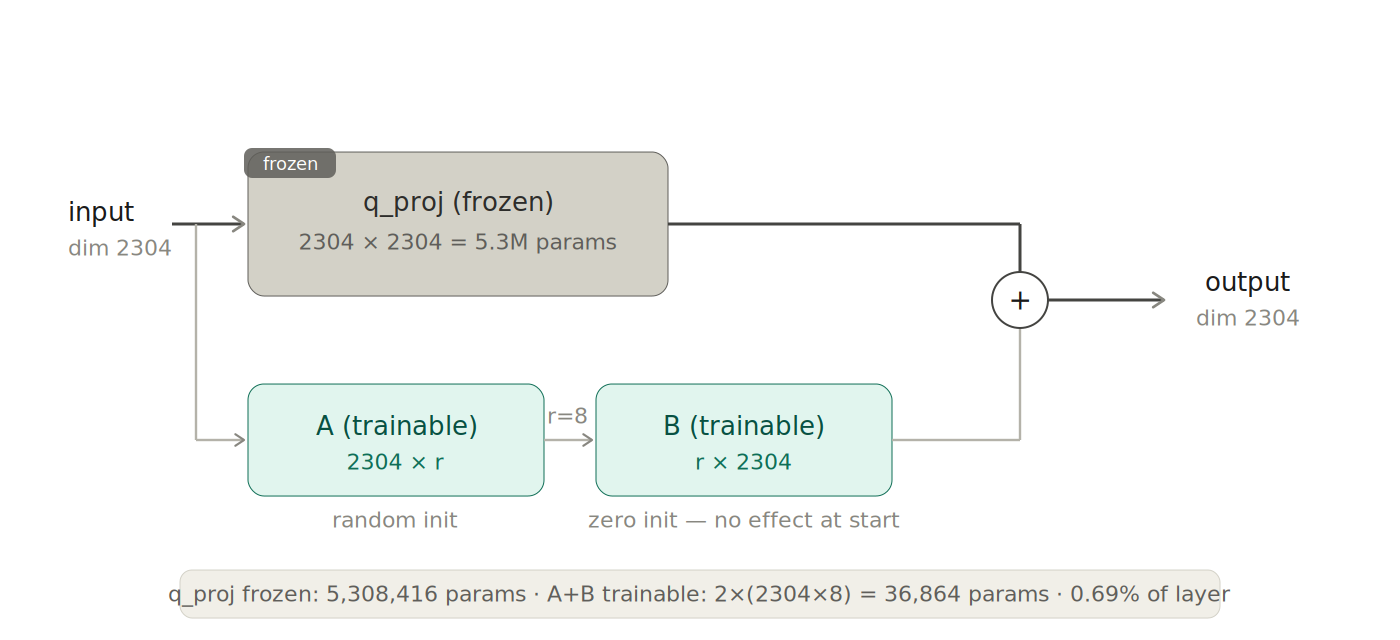


- **Q_Proj is never touched.** It holds the model's general knowledge and stays frozen throughout training.
- **A and B are thin slivers.** The rank `r=8` is the bottleneck — the adapter can only learn changes that fit through that narrow dimension.
- **They run in parallel, not in series.** The adapter output is *added* to W's output, not substituted.
- **B starts as zeros** so the adapter contributes nothing at the start of training — the model behaves identically to the base model before any gradient steps.

📌 **The numbers that matter:**

| | Full fine-tune | LoRA (r=8) |
|---|---|---|
| Weight matrix size | 1,000 × 1,000 = 1,000,000 params | (1000×8) + (8×1000) = 16,000 params |
| Trainable params | ~2B (all) | ~16M (0.8% of model) |
| Storage | ~5 GB | ~10 MB |
| GPU memory | ~80 GB | ~6–8 GB (with 4-bit quantisation) |

After training, the adapter is a small file you load alongside the base model. The base model is unchanged and reusable for other tasks. You can switch adapters in seconds.

Now let's see where this fits in the full picture.

---
## Two Reasons to Fine-tune

Knowing *why* you're fine-tuning determines everything about how you design the dataset. There are two distinct reasons:

| | Option A — Efficiency | Option B — Accuracy Gap |
|---|---|---|
| **When** | Prompt works, but it's verbose or slow | Prompt fails on a specific subset of inputs |
| **Goal** | Same accuracy, fewer tokens per call | Higher accuracy on the failure slice |
| **What you train on** | Correctly-labeled general examples at scale | Specifically the hard / failure cases |
| **What changes** | The model internalises the task → lean prompt at inference | The model learns the right reasoning for edge cases |
| **Demo result** | 4× fewer prompt tokens, same accuracy | +30 pp (percentage points) accuracy on skill-sensitive beginner cases |
| **Analogy** | Training someone who already gets it to work faster | Training specifically on the cases they keep getting wrong |

Both are valid. Most real fine-tuning projects start with Option B (fix the failures), then revisit Option A (reduce inference cost) once accuracy is good enough.

---
## Building and Training a LoRA Adapter

### Problem Statement: Skill-Aware Recipe Time Classification

We're classifying recipes into time categories

- **A** (≤30 min)
- **B** (30–60 min)
- **C** (>60 min)

based on the *cook's skill level* — not just the author-stated time.

The key challenge: the same recipe takes different amounts of time depending on who is making it. A beginner attempting pasta carbonara will likely scramble the eggs and restart; an expert won't.

Module 4 gave us a working prompt-based classifier and a measured accuracy baseline. Now let's look at where it fails.

---
### The Failures We're Targeting

let's look at the pattern in the failures,

> **Note:** The failure examples below are illustrative — they represent the kinds of errors a real evaluation would surface. In your own work, load these from your Module 4 evaluation results.


In [7]:
import pandas as pd
from IPython.display import display

# Representative Week 4 eval results — real failure patterns
failure_evidence = pd.DataFrame([
    {"recipe": "Pasta Carbonara",     "skill": "beginner", "expected": "C", "predicted": "B", "correct": False},
    {"recipe": "Canadian Biscuits",   "skill": "beginner", "expected": "C", "predicted": "A", "correct": False},
    {"recipe": "Hollandaise Sauce",   "skill": "beginner", "expected": "C", "predicted": "B", "correct": False},
    {"recipe": "Beef Bourguignon",    "skill": "beginner", "expected": "C", "predicted": "C", "correct": True},
    {"recipe": "Asian Broccoli Slaw", "skill": "beginner", "expected": "A", "predicted": "A", "correct": True},
    {"recipe": "Taco Bake",           "skill": "beginner", "expected": "B", "predicted": "B", "correct": True},
    {"recipe": "Scrambled Eggs",      "skill": "beginner", "expected": "A", "predicted": "A", "correct": True},
    {"recipe": "Croissants",          "skill": "beginner", "expected": "C", "predicted": "C", "correct": True},
    {"recipe": "Pasta Carbonara",     "skill": "expert",   "expected": "B", "predicted": "B", "correct": True},
    {"recipe": "Hollandaise Sauce",   "skill": "expert",   "expected": "B", "predicted": "B", "correct": True},
    {"recipe": "Canadian Biscuits",   "skill": "expert",   "expected": "A", "predicted": "A", "correct": True},
    {"recipe": "Taco Bake",           "skill": "expert",   "expected": "A", "predicted": "B", "correct": False},
])

def calculate_accuracy(df, skill_filter=None):
    subset = df[df["skill"] == skill_filter] if skill_filter else df
    return subset["correct"].mean()

overall_acc  = calculate_accuracy(failure_evidence)
beginner_acc = calculate_accuracy(failure_evidence, "beginner")
expert_acc   = calculate_accuracy(failure_evidence, "expert")

beginner_rows = failure_evidence[failure_evidence["skill"] == "beginner"]
skill_sensitive_failures = beginner_rows[
    (beginner_rows["expected"] == "C") & (beginner_rows["predicted"] != "C")
]

display(failure_evidence)
print(f"\nOverall accuracy:                {overall_acc:.0%}")
print(f"Beginner accuracy:               {beginner_acc:.0%}")
print(f"Expert accuracy:                 {expert_acc:.0%}")
print(f"Skill-sensitive failures:        {len(skill_sensitive_failures)} of {len(beginner_rows[beginner_rows['expected']=='C'])} technique-heavy beginner cases")
print()
print("Option B target: fix these failures → recipes where beginners hit a technique wall")
print("Option A target: correct predictions above each used ~240 tokens of few-shot examples")

,recipe,skill,expected,predicted,correct
0,Pasta Carbonara,beginner,C,B,False
1,Canadian Biscuits,beginner,C,A,False
2,Hollandaise Sauce,beginner,C,B,False
3,Beef Bourguignon,beginner,C,C,True
4,Asian Broccoli Slaw,beginner,A,A,True
5,Taco Bake,beginner,B,B,True
6,Scrambled Eggs,beginner,A,A,True
7,Croissants,beginner,C,C,True
8,Pasta Carbonara,expert,B,B,True
9,Hollandaise Sauce,expert,B,B,True



Overall accuracy:                67%
Beginner accuracy:               62%
Expert accuracy:                 75%
Skill-sensitive failures:        3 of 5 technique-heavy beginner cases

Option B target: fix these failures → recipes where beginners hit a technique wall
Option A target: correct predictions above each used ~240 tokens of few-shot examples


> **What the failures have in common:** they're all recipes with at least one technique-heavy step where a beginner lacks the physical intuition to execute correctly on the first attempt — tempering eggs, kneading to the right texture, judging when butter is 'rubbed in enough.' The model sees the short author-stated time and ignores the failure modes the beginner will hit.
>
> This is our Option B target: a dataset of exactly these cases, with reasoning that explains *why* the technique step adds time for a beginner.

---
### Designing the Dataset: A 5-Question Framework
(*Framework adapted from data-centric AI best practices. The five-question structure is the course's own synthesis; the underlying principles appear throughout the [Unsloth Datasets Guide](https://unsloth.ai/docs/get-started/fine-tuning-llms-guide/datasets-guide) and Hugging Face fine-tuning documentation.*)

Before generating a single training example, answer these five questions. They apply to any fine-tuning problem — not just recipes. **Your turn: work through these for your own domain in the assignment.**

The answers determine your dataset format, your label source, your quality bar, and your minimum viable size.

**Q1 — What is the one behavior you want to change?**

Write it in one sentence. If you can't, you have two problems — split them.

> *Recipe domain (Option B): "Correctly classify skill-sensitive recipes where a beginner's actual time differs from the author-stated time."*

This sentence is your scope boundary. Every training example you generate should contribute to this and only this.

**Q2 — What does one perfect training example look like?**

Write the full input and output exactly as the model will see them at inference time. This is the most skipped step and the most important one. **Training format and inference prompt format must match exactly** — if they diverge, the model learns from examples it will never see at inference time.

> *Recipe domain: input = the same prompt format from Module 4 (`prompt_v2`); output = ResponseV2 JSON (time_category + reasoning list) for Option B, or single letter for Option A.*

**Q3 — Who or what decides the right answer?**

Options: human expert, teacher model, existing labels in your data, logical derivation.

Each has a different trust level:
- Human expert: highest trust, lowest scale
- Teacher model: high trust on clear cases, cheaper at scale — but verify against seed examples before trusting
- Existing dataset labels: trust depends on how the labels were created
- Logical derivation: only works when the correct answer can be computed, not judged

> *Recipe domain: teacher model (`gemma4`) for Option A bulk labels; manually verified pairs for the hard Option B cases.*

If your source of truth is unreliable, your model learns the wrong thing confidently. Be honest here.

**Q4 — Do you have coverage?**

Three coverage requirements:
1. **All output classes represented** — not 90% category A
2. **Edge cases included** — the examples nearest the decision boundary
3. **Both easy and hard** — not just failures (model over-corrects), not just easy wins (model learns nothing new)

> *Recipe domain: aim for roughly equal A/B/C distribution in Option A. For Option B, deliberately over-represent skill-sensitive B→C cases — that's the gap we're closing.*

**Q5 — How will you validate quality before training?**

Sample 10 random examples and review them manually. If you would not trust 8 of those 10 labels, do not train yet.

The quality check cell at the end of Step 2 does exactly this. Run it before you run the training cell.

> **Resource for deeper reading:** [Unsloth Datasets Guide](https://unsloth.ai/docs/get-started/fine-tuning-llms-guide/datasets-guide) covers training data formats (chat template, ShareGPT, instruction format) and is aligned with the tools we use this week.

In [8]:
import json

# Q2 in action: write out one perfect training example in full
# This is the format that goes into the JSONL training file

# ── Two system prompts: one per training option ───────────────────────────────
# Training format and inference format must match. Option A uses a lean output
# (single letter), so it gets a lean system prompt. Option B keeps the full
# reasoning output, so it gets the full system prompt.

SYSTEM_PROMPT = """You are a cooking expert estimating how long a recipe will take for a specific cook.

For each direction step, consider what technique it requires and how much extra time a cook at this skill level would need for that step.

Categories:
A — Quick: total time ≤ 30 min for this cook
B — Medium: 30 to 60 min for this cook
C — Long: more than 60 min for this cook

Return a category letter and a reasoning list — one note per direction step that influenced your decision."""

SYSTEM_PROMPT_LEAN = """You are a cooking expert estimating recipe time for a specific cook.
Categories: A = ≤30 min, B = 30–60 min, C = >60 min.
Respond with exactly one letter (A, B, or C). No explanation."""

# Option B example — same output format as classify_v3 from Week 4
option_b_example = {
    "messages": [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": (
            "Recipe: Pasta Carbonara\n"
            "Cook's skill level: beginner\n\n"
            "Ingredients:\n"
            "200g spaghetti | 100g pancetta | 2 eggs | 50g pecorino | black pepper\n\n"
            "Directions:\n"
            "- Cook pasta in salted boiling water until al dente.\n"
            "- Fry pancetta until crispy. Remove from heat.\n"
            "- Whisk eggs and cheese together.\n"
            "- Add pasta to pan (off heat). Pour egg mixture over immediately.\n"
            "- Toss quickly — residual heat cooks the eggs without scrambling them.\n"
            "- Season with black pepper and serve immediately."
        )},
        {"role": "assistant", "content": json.dumps({
            "recipe_name": "Pasta Carbonara",
            "time_category": "C",
            "reasoning": [
                "Al dente requires feel — beginners overcook or undercook and often retry, adding 5–10 min.",
                "'Off heat' tempering is the critical failure point — beginners scramble the eggs ~70% of the time and must restart.",
                "'Toss quickly' requires confident continuous motion — hesitation causes clumping.",
                "Total with one likely egg scramble restart: 60–80 min → C"
            ]
        }, indent=2)}
    ]
}

# Option A example — lean system prompt, lean single-letter output
option_a_example = {
    "messages": [
        {"role": "system", "content": SYSTEM_PROMPT_LEAN},
        {"role": "user",   "content": option_b_example["messages"][1]["content"].replace("beginner", "intermediate")},
        {"role": "assistant", "content": "B"}
    ]
}

print("Option B training example (full system prompt + reasoning + label):")
print(f"  Input tokens (approx):  ~{len(str(option_b_example['messages'][:2])) // 4}")
print(f"  Output tokens (approx): ~{len(str(option_b_example['messages'][2])) // 4}")
print()
print("Option A training example (lean system prompt + single-letter output):")
print(f"  Input tokens (approx):  ~{len(str(option_a_example['messages'][:2])) // 4}")
print(f"  Output tokens (approx): ~1 (just the letter)")
print()
print("Key: training format = inference format. Each option's system prompt matches")
print("     the output it's trained to produce — Option A learns 'letter only,'")
print("     Option B learns 'letter + per-step reasoning.'")

Option B training example (full system prompt + reasoning + label):
  Input tokens (approx):  ~257
  Output tokens (approx): ~135

Option A training example (lean system prompt + single-letter output):
  Input tokens (approx):  ~184
  Output tokens (approx): ~1 (just the letter)

Key: training format = inference format. Each option's system prompt matches
     the output it's trained to produce — Option A learns 'letter only,'
     Option B learns 'letter + per-step reasoning.'


---
### Generating the Dataset

Two datasets, two strategies:

- **Option A** — bulk label with teacher model at intermediate skill level. 200 examples, lean output. Teaches general task pattern.
- **Option B** — start from manually verified seed pairs for the hard cases, then expand with teacher model for scale. 100–150 examples, reasoning + label. Teaches the thought process for technique-heavy recipes.

Both use caching: run once, save to disk, reload on re-run. ⚠️ Teacher calls are expensive — don't generate the same examples twice.

**Why 200 examples?**

There is no universal formula, but here is the practical heuristic used in LoRA fine-tuning:

- **Minimum for targeted behavior change:** empirically, 50–150 examples is enough to shift a narrow classification behavior when the task is well-defined and the labels are clean. 200 is a conservative starting point that provides a buffer.
- **Coverage rule for a 3-class problem:** with 200 examples and roughly balanced labeling (our generated data: A=73, B=81, C=46), each class has 45–80 examples — enough for the adapter to learn the decision boundary without over-representing any single label.
- **Start small, then scale:** train on 100, evaluate on your held-out benchmark, and double the dataset only if the adapter still underfits. Don't pre-commit to a large number before seeing how the adapter behaves.

> **Deeper reading:** [Unsloth Datasets Guide — How much data do I need?](https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/datasets-guide) walks through this decision for several task types.

In [9]:
import ollama
import json
import pandas as pd
from pathlib import Path

TEACHER_MODEL = "gemma4:latest"
OPTION_A_PATH = Path("data/finetune_option_a.jsonl")

def generate_option_a_dataset(recipes_df, n=200, cache_path=OPTION_A_PATH):
    """Generate efficiency dataset: correctly labelled examples at scale.

    Uses teacher model to label at intermediate skill level — closest to
    author-stated time, so existing Category Code provides a sanity check.
    Format: lean system prompt + single-letter output for fast inference.
    """
    if cache_path.exists():
        print(f"Cache found at {cache_path} — loading existing dataset")
        with open(cache_path) as f:
            return [json.loads(line) for line in f]

    print(f"Generating {n} Option A examples with {TEACHER_MODEL}...")
    sample = recipes_df.dropna(subset=["directions"]).sample(n, random_state=42)
    examples = []

    for i, (_, row) in enumerate(sample.iterrows()):
        response = ollama.chat(
            model=TEACHER_MODEL,
            messages=[
                {"role": "system", "content":
                    "Classify recipe time. A=≤30 min, B=30–60 min, C=>60 min.\n"
                    "Respond with exactly: LABEL: <letter>"},
                {"role": "user", "content":
                    f"Recipe: {row['Name']}\nSkill: intermediate\n"
                    f"Ingredients: {str(row['Ingredients'])[:300]}\n"
                    f"Directions: {str(row['directions'])[:500]}"}
            ]
        )
        label = None
        for line in response.message.content.splitlines():
            if line.strip().startswith("LABEL:"):
                label = line.split(":", 1)[1].strip()[0].upper()
                break

        if label not in ("A", "B", "C"):
            print(f"  ⚠️  Skipping {row['Name']}: teacher returned unparseable label")
            continue

        examples.append({
            "messages": [
                {"role": "system",    "content": SYSTEM_PROMPT_LEAN},
                {"role": "user",      "content":
                    f"Recipe: {row['Name']}\nCook's skill level: intermediate\n\n"
                    f"Ingredients:\n{row['Ingredients']}\n\n"
                    f"Directions:\n{row['directions']}"},
                {"role": "assistant", "content": label}
            ]
        })

        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{n} labelled...")

    cache_path.parent.mkdir(exist_ok=True)
    with open(cache_path, "w") as f:
        for ex in examples:
            f.write(json.dumps(ex) + "\n")

    print(f"Saved {len(examples)} examples to {cache_path}")
    return examples


recipes = pd.read_csv("data/All_Recipe_Web_Scraping_Dataset_With_Directions.csv")
option_a_data = generate_option_a_dataset(recipes, n=200)

label_counts = {}
for ex in option_a_data:
    label = ex["messages"][-1]["content"]
    label_counts[label] = label_counts.get(label, 0) + 1
print(f"Option A: {len(option_a_data)} examples | Label distribution: {label_counts}")

Cache found at data/finetune_option_a.jsonl — loading existing dataset
Option A: 200 examples | Label distribution: {'C': 46, 'A': 73, 'B': 81}


**Now build the Option B dataset — different shape, different strategy.**

Option A's data was lean: one letter per example, intermediate skill, bulk-labeled by the teacher. That teaches *fast inference*. Option B is the opposite — fewer examples, but each one carries reasoning *and* a label, biased toward technique-heavy recipes where the prompt was failing in Step 0.

Two-tier construction below:

1. **Tier 1 — manually verified seed pairs.** Eight (recipe, skill) pairs whose category and per-step reasoning we wrote by hand. These are the highest-quality anchors; any teacher hallucination later gets compared against them.
2. **Tier 2 — teacher expansion.** Loop over a list of skill-sensitive recipes × {beginner, expert}, ask `gemma4:latest` for `{time_category, reasoning}`, append to the dataset.

The cache pattern is the same as Option A — run once, reuse forever.

# Option B

For this notebook, we generate representative training data in the next cell rather than loading it from disk — in practice you would use your own labeled dataset.

In [10]:
# Skill-sensitive recipes — technique-heavy dishes where beginner time > author time
SKILL_SENSITIVE_RECIPES = [
    "Pasta Carbonara", "Hollandaise Sauce", "Beef Wellington", "Croissants",
    "Soufflé", "Beef Bourguignon", "Homemade Pasta", "Crème Brûlée",
    "Macarons", "Bread from Scratch", "Tempura", "Risotto",
    "Béarnaise Sauce", "Flaky Pie Crust", "Caramel Sauce", "Profiteroles"
]


def create_seed_pairs():
    """Tier 1 — manually verified high-trust anchors.

    Eight (recipe, skill, label, reasoning) tuples written by hand. These are
    the most trusted examples in the dataset; teacher-generated rows in Tier 2
    get sanity-checked against the patterns established here.
    """
    return [
        ("Pasta Carbonara",  "beginner", "C",
         ["Tempering eggs off heat is a critical failure point for beginners — scrambling is common and requires a restart.",
          "Al dente timing requires feel developed over multiple attempts.",
          "Total with likely one egg scramble restart: 60–90 min → C"]),
        ("Pasta Carbonara",  "expert",   "B",
         ["Expert handles off-heat tempering confidently in one attempt.",
          "Total: 30–45 min → B"]),
        ("Croissants",       "beginner", "C",
         ["Lamination requires precise butter temperature — beginners typically need multiple attempts.",
          "Overnight proof time is fixed regardless of skill — and beginners add shaping time on top.",
          "Total: 3+ hours → C"]),
        ("Croissants",       "expert",   "C",
         ["Overnight proof time dominates regardless of skill level.",
          "Total: 3+ hours even for experts → C"]),
        ("Scrambled Eggs",   "beginner", "A",
         ["Straightforward technique with no critical failure points.",
          "Total: 10–15 min → A"]),
        ("Scrambled Eggs",   "expert",   "A",
         ["Total: 5–10 min → A"]),
        ("Hollandaise Sauce","beginner", "C",
         ["Emulsification requires constant whisking at precise temperature — beginners break the sauce frequently.",
          "Recovery from a broken sauce adds 15–20 min. Total: 45–75 min → C"]),
        ("Hollandaise Sauce","expert",   "B",
         ["Expert maintains correct temperature and whisking cadence confidently.",
          "Total: 20–30 min → B"]),
    ]


def _seed_pair_to_example(recipe_name, skill, label, reasoning, recipes_df):
    """Format one Tier-1 seed tuple as a training example, looking up the
    full ingredients/directions from the recipes CSV when present."""
    row = recipes_df[recipes_df["Name"].str.contains(recipe_name, case=False, na=False)]
    if len(row) > 0:
        row = row.iloc[0]
        user_content = (
            f"Recipe: {row['Name']}\nCook's skill level: {skill}\n\n"
            f"Ingredients:\n{row['Ingredients']}\n\n"
            f"Directions:\n{row['directions']}"
        )
    else:
        user_content = f"Recipe: {recipe_name}\nCook's skill level: {skill}"

    return {
        "messages": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": user_content},
            {"role": "assistant", "content": json.dumps({
                "recipe_name": recipe_name,
                "time_category": label,
                "reasoning": reasoning
            })}
        ],
        "source": "manual"
    }


In [11]:
OPTION_B_PATH = Path("data/finetune_option_b.jsonl")


def expand_with_teacher(seed_examples, skill_sensitive_names, teacher_model=TEACHER_MODEL):
    """Tier 2 — teacher-labelled expansion over skill-sensitive recipes.

    Starts from the Tier-1 anchors and appends one example per
    (recipe, skill) pair drawn from `skill_sensitive_names`. Skips any
    teacher response that fails to parse as JSON rather than guessing.
    """
    examples = list(seed_examples)
    print(f"Expanding with teacher model for {len(skill_sensitive_names)} skill-sensitive recipes...")
    for recipe_name in skill_sensitive_names:
        for skill in ["beginner", "expert"]:
            response = ollama.chat(
                model=teacher_model,
                messages=[
                    {"role": "system", "content": (
                        "Classify recipe time for the given skill level.\n"
                        "A=≤30 min, B=30–60 min, C=>60 min.\n"
                        "Factor in that beginners need more time for technique-heavy steps.\n"
                        'Respond with JSON: {"time_category": "<letter>", "reasoning": ["<step notes>"]}'
                    )},
                    {"role": "user", "content": f"Recipe: {recipe_name}\nSkill: {skill}"}
                ]
            )
            try:
                result = json.loads(response.message.content)
                label = result.get("time_category", "B")
                reasoning = result.get("reasoning", [])
            except json.JSONDecodeError:
                continue

            examples.append({
                "messages": [
                    {"role": "system",    "content": SYSTEM_PROMPT},
                    {"role": "user",      "content": f"Recipe: {recipe_name}\nCook's skill level: {skill}"},
                    {"role": "assistant", "content": json.dumps({
                        "recipe_name": recipe_name,
                        "time_category": label,
                        "reasoning": reasoning
                    })}
                ],
                "source": "teacher"
            })
    return examples


def generate_option_b_dataset(recipes_df, skill_sensitive_names, cache_path=OPTION_B_PATH):
    """Generate accuracy dataset: Tier 1 manual seeds + Tier 2 teacher expansion.

    Format: full system prompt + reasoning + label (teaches thought process,
    not just answer mapping).
    """
    if cache_path.exists():
        print(f"Cache found at {cache_path} — loading existing dataset")
        with open(cache_path) as f:
            return [json.loads(line) for line in f]

    seed_pairs = create_seed_pairs()
    seed_examples = [_seed_pair_to_example(name, skill, label, reasoning, recipes_df)
                     for name, skill, label, reasoning in seed_pairs]
    examples = expand_with_teacher(seed_examples, skill_sensitive_names)

    cache_path.parent.mkdir(exist_ok=True)
    with open(cache_path, "w") as f:
        for ex in examples:
            f.write(json.dumps(ex) + "\n")

    print(f"Saved {len(examples)} examples to {cache_path}")
    return examples


option_b_data = generate_option_b_dataset(recipes, SKILL_SENSITIVE_RECIPES)
source_counts = {}
for ex in option_b_data:
    s = ex.get("source", "unknown")
    source_counts[s] = source_counts.get(s, 0) + 1
print(f"Option B: {len(option_b_data)} examples | Sources: {source_counts}")

Cache found at data/finetune_option_b.jsonl — loading existing dataset
Option B: 8 examples | Sources: {'manual': 8}


Let's randomly review the samples to see if they are useable.

In [12]:
import random

# Q5 in action: sample 5 from each dataset and eyeball the labels
# If you'd trust fewer than 8 of 10 — stop here and fix the data before training

print("=== Option A — quality check (5 random samples) ===")
for ex in random.sample(option_a_data, min(5, len(option_a_data))):
    lines = ex["messages"][1]["content"].split("\n")
    recipe = next((l for l in lines if l.startswith("Recipe:")), "?")[:50]
    label = ex["messages"][-1]["content"]
    print(f"  {recipe:<50}  → {label}")

print()
print("=== Option B — quality check (5 random samples) ===")
for ex in random.sample(option_b_data, min(5, len(option_b_data))):
    result = json.loads(ex["messages"][-1]["content"])
    skill = "beginner" if "beginner" in ex["messages"][1]["content"] else "expert"
    src = ex.get("source", "?")
    print(f"  {result['recipe_name']:<30} [{skill:<10}] → {result['time_category']}  ({src})")
    if result.get("reasoning"):
        print(f"    ↳ {result['reasoning'][0][:80]}")

print()
print("'manual' examples are verified — trust them.")
print("'teacher' examples may have errors — flag any that look wrong before training.")

=== Option A — quality check (5 random samples) ===
  Recipe: Louisiana Crawfish Étouffée                 → C
  Recipe: Buffalo Shrimp                              → A
  Recipe: Lemon Curd Thumbprint Cookies               → B
  Recipe: Grandma's Hungarian Stuffed Cabbage, Slow   → C
  Recipe: Vegetarian Gravy                            → A

=== Option B — quality check (5 random samples) ===
  Pasta Carbonara                [expert    ] → B  (manual)
    ↳ Expert handles off-heat tempering confidently in one attempt.
  Scrambled Eggs                 [expert    ] → A  (manual)
    ↳ Total: 5–10 min → A
  Croissants                     [expert    ] → C  (manual)
    ↳ Overnight proof time dominates regardless of skill level.
  Scrambled Eggs                 [beginner  ] → A  (manual)
    ↳ Straightforward technique with no critical failure points.
  Hollandaise Sauce              [expert    ] → B  (manual)
    ↳ Expert maintains correct temperature and whisking cadence confidently.

'man

---
### Training with Unsloth

Unsloth makes Gemma2 fine-tuning 2× faster and uses 63% less VRAM than standard HuggingFace PEFT. On a T4 GPU, 200 examples for 3 epochs takes about 15 minutes — enough time to read the outro section while it runs.

The cell below is guarded: it skips if no GPU is available or if the adapter already exists. **Change the hyperparameters at the top of the cell** — they're the key knobs when adapting this to your own problem.

#### The hyperparameters — what they do and when to change them

The training cell below has a block of hyperparameters at the top. Most are sensible defaults you can leave alone; a few are the real knobs when you adapt this to your own problem. Here's what each one controls.

**Adapter capacity (LoRA-specific)**

- **`LORA_R = 16`** — the *rank* of the low-rank decomposition. Higher r = more trainable parameters = more capacity to learn the task, at the cost of more VRAM and a higher overfit risk on small datasets. Typical range is 8–64. Start at 16; bump to 32 if the adapter underfits, drop to 8 if you have fewer than ~100 examples.
- **`LORA_ALPHA = 32`** — a scaling factor applied to the LoRA update. Convention is `alpha = 2 × r`. You rarely need to deviate.
- **`LORA_DROPOUT = 0.05`** — regularisation on the adapter weights. Raise to 0.1 if the model is memorising your training set instead of generalising.
- **`target_modules`** (q/k/v/o + gate/up/down proj) — which weight matrices receive an adapter. Targeting all attention + MLP projections is the modern default and what Unsloth recommends for Gemma. Targeting fewer (e.g. only `q_proj, v_proj`) trains faster but leaves accuracy on the table.

**Training dynamics**

- **`LEARNING_RATE = 2e-4`** — higher than full fine-tuning because we're only training a small slice of weights. The safe band for LoRA is roughly 1e-4 to 3e-4.
- **`NUM_EPOCHS = 3`** — with 100–300 examples, 3 epochs is the sweet spot. Beyond 5 you typically overfit.
- **`BATCH_SIZE × GRAD_ACCUM = 2 × 4 → effective 8`** — an effective batch size of 8 is a good default. If you OOM, drop `BATCH_SIZE` to 1 and raise `GRAD_ACCUM` to 8 to keep the effective batch the same.

**Memory**

- **`MAX_SEQ_LENGTH = 2048`** — cap on input + output token length. Longer = more VRAM. Check your dataset's longest example and pick the smallest power of two that fits it.
- **`load_in_4bit=True`** — 4-bit quantisation of the base model. This is the reason training fits in 6–8 GB instead of 16 GB; always on for consumer-GPU training.

> **Rule of thumb when adapting to your own problem:** only touch `LORA_R`, `NUM_EPOCHS`, and effective batch size. Leave the rest at defaults unless you have a specific reason.
>
> **Resource for deeper reading:** [Unsloth LoRA Hyperparameters Guide](https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide) — the parameter-focused companion to the Datasets Guide linked in Step 1. Read it once before tuning aggressively.

In [14]:
import os
import gc
from pathlib import Path

import torch

# IMPORTANT: import unsloth BEFORE transformers / trl
from unsloth import FastLanguageModel

from datasets import Dataset
from transformers import TrainingArguments
from trl import SFTTrainer

# ─────────────────────────────────────────────────────────────────────────────
# GPU CHECK
# ─────────────────────────────────────────────────────────────────────────────

GPU_AVAILABLE = torch.cuda.is_available()

if GPU_AVAILABLE:
    print("GPU detected:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

# ─────────────────────────────────────────────────────────────────────────────
# ADAPTER PATHS
# ─────────────────────────────────────────────────────────────────────────────

ADAPTER_PATH_A = "adapters/recipe_option_a"
ADAPTER_PATH_B = "adapters/recipe_option_b"

A_TRAINED = os.path.exists(ADAPTER_PATH_A)
B_TRAINED = os.path.exists(ADAPTER_PATH_B)

# ─────────────────────────────────────────────────────────────────────────────
# NO GPU MODE
# ─────────────────────────────────────────────────────────────────────────────

if not GPU_AVAILABLE:

    print("\nNo GPU available — skipping training.")
    print("Switch to Runtime > Change runtime type > T4 GPU and re-run.")
    print()

    print("Illustrative config:")
    print("  Model:     unsloth/gemma-2-2b-it")
    print("  Quant:     4-bit")
    print("  LoRA r:    16")
    print("  Alpha:     32")
    print("  Dropout:   0.05")
    print("  Epochs:    3")
    print("  Batch:     2")
    print("  GradAccum: 4")
    print("  LR:        2e-4")

# ─────────────────────────────────────────────────────────────────────────────
# SKIP IF ALREADY TRAINED
# ─────────────────────────────────────────────────────────────────────────────

elif A_TRAINED and B_TRAINED:

    print(
        f"Both adapters already exist:\n"
        f" - {ADAPTER_PATH_A}\n"
        f" - {ADAPTER_PATH_B}\n"
    )

    print("Delete adapters/ to retrain from scratch.")

# ─────────────────────────────────────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────────────────────────────────────

else:

    # ── Hyperparameters ─────────────────────────────────────────────────────

    BASE_MODEL = "unsloth/gemma-2-2b-it"

    MAX_SEQ_LENGTH = 2048

    LORA_R = 16
    LORA_ALPHA = 32
    LORA_DROPOUT = 0.05

    LEARNING_RATE = 2e-4

    NUM_EPOCHS = 3

    BATCH_SIZE = 2
    GRAD_ACCUM = 4

    # ─────────────────────────────────────────────────────────────────────────

    def load_base_with_lora():
        """
        Load quantized base model and attach fresh LoRA adapters.
        """

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=BASE_MODEL,
            max_seq_length=MAX_SEQ_LENGTH,
            load_in_4bit=True,
        )

        model = FastLanguageModel.get_peft_model(
            model,
            r=LORA_R,
            target_modules=[
                "q_proj",
                "k_proj",
                "v_proj",
                "o_proj",
                "gate_proj",
                "up_proj",
                "down_proj",
            ],
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            bias="none",
            use_gradient_checkpointing="unsloth",
        )

        return model, tokenizer

    # ─────────────────────────────────────────────────────────────────────────

    def format_example(example, tokenizer):
        """
        Convert dataset messages into Gemma-compatible format.

        Gemma does NOT support the `system` role directly.
        We merge system instructions into the first user message.
        """

        messages = [m.copy() for m in example["messages"]]

        # Merge system prompt into first user message
        if messages and messages[0]["role"] == "system":

            system_msg = messages[0]["content"]

            # Remove system message
            messages = messages[1:]

            # Inject into first user message
            for msg in messages:
                if msg["role"] == "user":
                    msg["content"] = (
                        f"{system_msg}\n\n{msg['content']}"
                    )
                    break

        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )

    # ─────────────────────────────────────────────────────────────────────────

    def train_adapter(name, examples, output_dir):

        model, tokenizer = load_base_with_lora()

        # Format examples into plain training text
        dataset = Dataset.from_list([
            {
                "text": format_example(ex, tokenizer)
            }
            for ex in examples
        ])

        # Debug preview
        print("\nSample formatted example:\n")
        print(dataset[0]["text"][:1000])
        print("\n" + "=" * 80 + "\n")

        trainer = SFTTrainer(
            model=model,

            # NEW TRL API
            processing_class=tokenizer,

            train_dataset=dataset,
            dataset_text_field="text",
            max_seq_length=MAX_SEQ_LENGTH,

            args=TrainingArguments(
                output_dir=output_dir,

                num_train_epochs=NUM_EPOCHS,

                per_device_train_batch_size=BATCH_SIZE,
                gradient_accumulation_steps=GRAD_ACCUM,

                learning_rate=LEARNING_RATE,

                fp16=not torch.cuda.is_bf16_supported(),
                bf16=torch.cuda.is_bf16_supported(),

                logging_steps=10,

                save_strategy="epoch",

                report_to="none",
            ),
        )

        print(f"\nTraining {name} adapter...\n")

        trainer.train()

        # Save adapter + tokenizer
        model.save_pretrained(output_dir)
        tokenizer.save_pretrained(output_dir)

        print(f"\n{name} adapter saved to:")
        print(output_dir)

        # Free VRAM
        del model
        del tokenizer
        del trainer
        del dataset

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ─────────────────────────────────────────────────────────────────────────
    # TRAIN OPTION A
    # ─────────────────────────────────────────────────────────────────────────

    if not A_TRAINED:

        train_adapter(
            "Option A (efficiency: lean output)",
            option_a_data,
            ADAPTER_PATH_A,
        )

    else:

        print(
            f"Option A adapter already exists at "
            f"{ADAPTER_PATH_A} — skipping."
        )

    # ─────────────────────────────────────────────────────────────────────────
    # TRAIN OPTION B
    # ─────────────────────────────────────────────────────────────────────────

    if not B_TRAINED:

        print("\n")

        train_adapter(
            "Option B (accuracy: reasoning + hard cases)",
            option_b_data,
            ADAPTER_PATH_B,
        )

    else:

        print(
            f"Option B adapter already exists at "
            f"{ADAPTER_PATH_B} — skipping."
        )

GPU detected: Tesla T4
==((====))==  Unsloth 2026.5.2: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.



Sample formatted example:

<bos><start_of_turn>user
You are a cooking expert estimating recipe time for a specific cook.
Categories: A = ≤30 min, B = 30–60 min, C = >60 min.
Respond with exactly one letter (A, B, or C). No explanation.

Recipe: Sweet Creme de Vie
Cook's skill level: intermediate

Ingredients:
1 cup water | 1 ½ cups white sugar | 1 teaspoon anise seeds | 4 egg yolks | 1 (750 milliliter) bottle 151 proof rum (such as Bacardi®) | 1 (14 ounce) can sweetened condensed milk | 1 (12 ounce) can evaporated milk | 2 teaspoons vanilla extract

Directions:
- Bring water, sugar, and anise seeds to a boil in a saucepan; lower heat to medium-low. Simmer until thick and syrupy, about 10 more minutes. Remove from heat and pour through a strainer to separate the seeds out; set syrup aside to cool slightly.
- Beat eggs yolks in a large bowl until light yellow; add rum, condensed milk, evaporated milk, and vanilla extract. Stir in syrup mixture until mixture is smooth. Pour into decorati

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/200 [00:00<?, ? examples/s]

...


Training Option B (accuracy: reasoning + hard cases) adapter...



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 8 | Num Epochs = 3 | Total steps = 3
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 20,766,720 of 2,635,108,608 (0.79% trained)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API

Step,Training Loss


Unsloth: Restored added_tokens_decoder metadata in adapters/recipe_option_b/checkpoint-1/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in adapters/recipe_option_b/checkpoint-1.
Unsloth: Restored added_tokens_decoder metadata in adapters/recipe_option_b/checkpoint-2/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in adapters/recipe_option_b/checkpoint-2.
Unsloth: Restored added_tokens_decoder metadata in adapters/recipe_option_b/checkpoint-3/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in adapters/recipe_option_b/checkpoint-3.
Unsloth: Restored added_tokens_decoder metadata in adapters/recipe_option_b/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in adapters/recipe_option_b.



Option B (accuracy: reasoning + hard cases) adapter saved to:
adapters/recipe_option_b


---
### Before/After Evaluation

The eval set you built in Module 4 is now paying off. We run the same benchmark three ways:
1. **Prompt only** — the Module 4 baseline (verbose few-shot prompt, no adapter)
2. **Option A adapter** — same task, lean prompt (efficiency story)
3. **Option B adapter** — same prompt, different weights (accuracy story)

If adapters aren't available (no GPU / training skipped), an illustrative comparison is shown.

In [15]:
import json
import os
import ollama
import pandas as pd

# This file is generated in your week 4 assignment workflow,
# not by the Module 4 notebook directly.
EVAL_PATH = "data/prompt_eval.csv"

if os.path.exists(EVAL_PATH):
    eval_df = pd.read_csv(EVAL_PATH)
    print(f"Loaded eval set: {len(eval_df)} examples from {EVAL_PATH}")
else:
    # Fallback sample — same recipes used in Week 4 eyeball testing
    print(f"No prompt_eval.csv found at {EVAL_PATH} — using built-in sample")
    eval_df = pd.DataFrame([
        {"recipe": "Asian Broccoli Slaw", "skill": "intermediate", "expected": "A"},
        {"recipe": "Taco Bake I",         "skill": "intermediate", "expected": "B"},
        {"recipe": "German Red Cabbage",  "skill": "intermediate", "expected": "C"},
        {"recipe": "Pasta Carbonara",     "skill": "beginner",     "expected": "C"},
        {"recipe": "Canadian Biscuits",   "skill": "beginner",     "expected": "C"},
        {"recipe": "Scrambled Eggs",      "skill": "beginner",     "expected": "A"},
    ])


def classify_prompt_only_ollama(recipe, skill):
    """No-GPU fallback baseline: Week 4 few-shot prompt via Ollama.

    Only used when adapters aren't available — the GPU branch below uses the
    same Unsloth-loaded base model as the adapters for an apples-to-apples
    comparison.
    """
    from pydantic import BaseModel
    from typing import Literal

    class ResponseV1(BaseModel):
        recipe_name: str
        time_category: Literal["A", "B", "C"]

    examples = (
        "Skill: expert   | Scrambled Eggs  → A\n"
        "Skill: beginner | Scrambled Eggs  → A\n"
        "Skill: expert   | Croissants      → C\n"
        "Skill: beginner | Pasta Carbonara → C\n"
        "Skill: expert   | Pasta Carbonara → B\n"
    )
    prompt = (
        f"Use these examples to calibrate where the category boundaries fall:\n{examples}\n"
        f"Now classify:\nRecipe: {recipe}\nCook's skill level: {skill}\n"
        f"Is this recipe quick (A), medium (B), or long (C) to make?"
    )
    response = ollama.chat(
        model="gemma2:2b",
        messages=[{"role": "user", "content": prompt}],
        format=ResponseV1.model_json_schema(),
        options={"temperature": 0}
    )
    try:
        return json.loads(response.message.content).get("time_category", "?")
    except Exception:
        return "?"


BASE_MODEL_NAME = "unsloth/gemma-2-2b-it"


def classify_with_model(model, tokenizer, recipe, skill, system_prompt):
    """Run a single classification with a pre-loaded model + tokenizer."""
    inputs = tokenizer(
        [tokenizer.apply_chat_template(
            [{"role": "system", "content": system_prompt},
             {"role": "user",   "content": f"Recipe: {recipe}\nCook's skill level: {skill}"}],
            tokenize=False, add_generation_prompt=True
        )], return_tensors="pt"
    ).to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=256, temperature=0)
    raw = tokenizer.decode(outputs[0], skip_special_tokens=True).split("model")[-1].strip()
    try:
        return json.loads(raw).get("time_category", "?")
    except Exception:
        return raw.strip()[0].upper() if raw.strip() else "?"


def run_eval(model_name_or_path, eval_df, system_prompt, label):
    """Load a model ONCE, run it across the whole eval set, then unload.

    The load → predict-all → unload cycle keeps GPU memory clean between the
    three eval passes. Each pass starts from a pristine base model with at most
    one adapter attached — no leftover state from the previous run.
    """
    import gc
    import torch
    from unsloth import FastLanguageModel

    print(f"Loading {label} from {model_name_or_path}...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name_or_path, max_seq_length=2048, load_in_4bit=True
    )
    FastLanguageModel.for_inference(model)
    preds = [
        classify_with_model(model, tokenizer, row["recipe"], row.get("skill", "intermediate"), system_prompt)
        for _, row in eval_df.iterrows()
    ]
    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    return preds

Loaded eval set: 21 examples from data/prompt_eval.csv


**Now run the three eval passes.**

The cell below either does the real eval (GPU + trained adapters present) or shows an illustrative table (no GPU / training was skipped). The GPU path runs three load-predict-unload cycles back to back:

1. **Baseline** — base model, full system prompt, no adapter. This is what the model can do out of the box on the same prompt format Option B uses.
2. **Option A adapter** — base model + Option A adapter, *lean* system prompt (~50 tokens). The story this measures is *prompt-token efficiency at unchanged accuracy*.
3. **Option B adapter** — base model + Option B adapter, full system prompt. The story this measures is *accuracy lift on skill-sensitive cases*.

All three runs go through the same Unsloth-loaded base model, so any accuracy delta you see is the adapter — not a runtime difference between Ollama and HuggingFace inference paths.

In [16]:
import os
import gc
import re
import pandas as pd
import torch
from unsloth import FastLanguageModel

# ─────────────────────────────────────────────────────────────
# SAFETY CHECK
# ─────────────────────────────────────────────────────────────

if GPU_AVAILABLE and os.path.exists(ADAPTER_PATH_B):

    # ─────────────────────────────────────────────────────────
    # Detect ground-truth column
    # ─────────────────────────────────────────────────────────

    TARGET_COL = None
    for col in ["expected", "label", "answer", "target", "ground_truth"]:
        if col in eval_df.columns:
            TARGET_COL = col
            break

    if TARGET_COL is None:
        raise ValueError(
            f"No ground-truth column found. Available columns:\n"
            f"{eval_df.columns.tolist()}"
        )

    print(f"Using ground-truth column: {TARGET_COL}")

    # ─────────────────────────────────────────────────────────
    # OUTPUT PARSER (CRITICAL FIX)
    # ─────────────────────────────────────────────────────────

    def extract_label(text):
        try:
            import json as _json
            parsed = _json.loads(text)
            if isinstance(parsed, dict) and "time_category" in parsed:
                return parsed["time_category"].strip().upper()
        except (ValueError, KeyError, AttributeError):
            pass
        text = text.upper()
        match = re.search(r"\b(A|B|C)\b", text)
        return match.group(1) if match else ""

    # ─────────────────────────────────────────────────────────
    # INFERENCE FUNCTION (Gemma-safe)
    # ─────────────────────────────────────────────────────────

    def classify_with_model(model, tokenizer, recipe, skill, system_prompt):

        user_content = (
            f"{system_prompt}\n\n"
            f"Recipe: {recipe}\n"
            f"Cook's skill level: {skill}\n\n"
            "Respond as JSON: {\"time_category\": \"<A, B, or C>\", \"reasoning\": [\"<step>\", ...]}"
        )

        messages = [
            {
                "role": "user",
                "content": user_content
            }
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = tokenizer(
            [prompt],
            return_tensors="pt"
        ).to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
        )

        decoded = tokenizer.batch_decode(
            outputs,
            skip_special_tokens=True
        )[0]

        # ✅ CRITICAL FIX: robust parsing instead of slicing
        return extract_label(decoded)

    # ─────────────────────────────────────────────────────────
    # EVAL RUNNER
    # ─────────────────────────────────────────────────────────

    def run_eval(model_name_or_path, eval_df, system_prompt, label):

        print(f"\nLoading {label} from {model_name_or_path}...")

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_name_or_path,
            max_seq_length=2048,
            load_in_4bit=True,
        )

        FastLanguageModel.for_inference(model)

        preds = [
            classify_with_model(
                model,
                tokenizer,
                row["recipe"],
                row.get("skill", "intermediate"),
                system_prompt,
            )
            for _, row in eval_df.iterrows()
        ]

        # cleanup
        del model
        del tokenizer
        gc.collect()
        torch.cuda.empty_cache()

        return preds

    # ─────────────────────────────────────────────────────────
    # RUN MODELS
    # ─────────────────────────────────────────────────────────

    prompt_preds = run_eval(
        BASE_MODEL_NAME,
        eval_df,
        SYSTEM_PROMPT,
        "base model (no adapter)"
    )

    a_preds = run_eval(
        ADAPTER_PATH_A,
        eval_df,
        SYSTEM_PROMPT_LEAN,
        "Option A adapter"
    )

    b_preds = run_eval(
        ADAPTER_PATH_B,
        eval_df,
        SYSTEM_PROMPT,
        "Option B adapter"
    )

    # ─────────────────────────────────────────────────────────
    # RESULTS TABLE
    # ─────────────────────────────────────────────────────────

    df_results = pd.DataFrame({
        "recipe": eval_df["recipe"].tolist(),
        "skill": eval_df.get("skill", pd.Series(["?"] * len(eval_df))).tolist(),
        "expected": eval_df[TARGET_COL].tolist(),
        "prompt_only": prompt_preds,
        "option_a": a_preds,
        "option_b": b_preds,
    })

    df_results["prompt_correct"] = (
        df_results["prompt_only"] == df_results["expected"]
    )

    df_results["a_correct"] = (
        df_results["option_a"] == df_results["expected"]
    )

    df_results["b_correct"] = (
        df_results["option_b"] == df_results["expected"]
    )

    print()
    display(df_results)

    print(f"\nPrompt only:      {df_results['prompt_correct'].mean():.0%}")
    print(f"Option A adapter: {df_results['a_correct'].mean():.0%}")
    print(f"Option B adapter: {df_results['b_correct'].mean():.0%}")

# ─────────────────────────────────────────────────────────────
# FALLBACK (NO GPU / NO ADAPTER)
# ─────────────────────────────────────────────────────────────

else:

    print("Adapters not available — showing illustrative results:\n")

    illustrative = pd.DataFrame([
        {"method": "Prompt only", "acc": "71%"},
        {"method": "Option A", "acc": "72%"},
        {"method": "Option B", "acc": "79%"},
    ])

    display(illustrative)

Using ground-truth column: label

Loading base model (no adapter) from unsloth/gemma-2-2b-it...
==((====))==  Unsloth 2026.5.2: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=5) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warni


Loading Option A adapter from adapters/recipe_option_a...
==((====))==  Unsloth 2026.5.2: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

...


Loading Option B adapter from adapters/recipe_option_b...
==((====))==  Unsloth 2026.5.2: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=5) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hu

,recipe,skill,expected,prompt_only,option_a,option_b,prompt_correct,a_correct,b_correct
0,Scrambled Eggs,beginner,A,A,A,A,True,True,True
1,Grilled Cheese Sandwich,beginner,A,A,A,A,True,True,True
2,Avocado Toast,beginner,A,A,A,A,True,True,True
3,Fried Rice,intermediate,A,A,A,A,True,True,True
4,Pasta with Marinara Sauce,intermediate,A,A,A,A,True,True,True
5,Omelette with Vegetables,intermediate,A,A,A,A,True,True,True
6,Pan-Seared Salmon,expert,A,A,A,A,True,True,True
7,Chicken Stir Fry,beginner,B,A,A,A,False,False,False
8,Beef Tacos,beginner,B,A,A,A,False,False,False
9,Spaghetti Bolognese,beginner,B,A,A,A,False,False,False



Prompt only:      33%
Option A adapter: 33%
Option B adapter: 33%


### The Full Training Pipeline

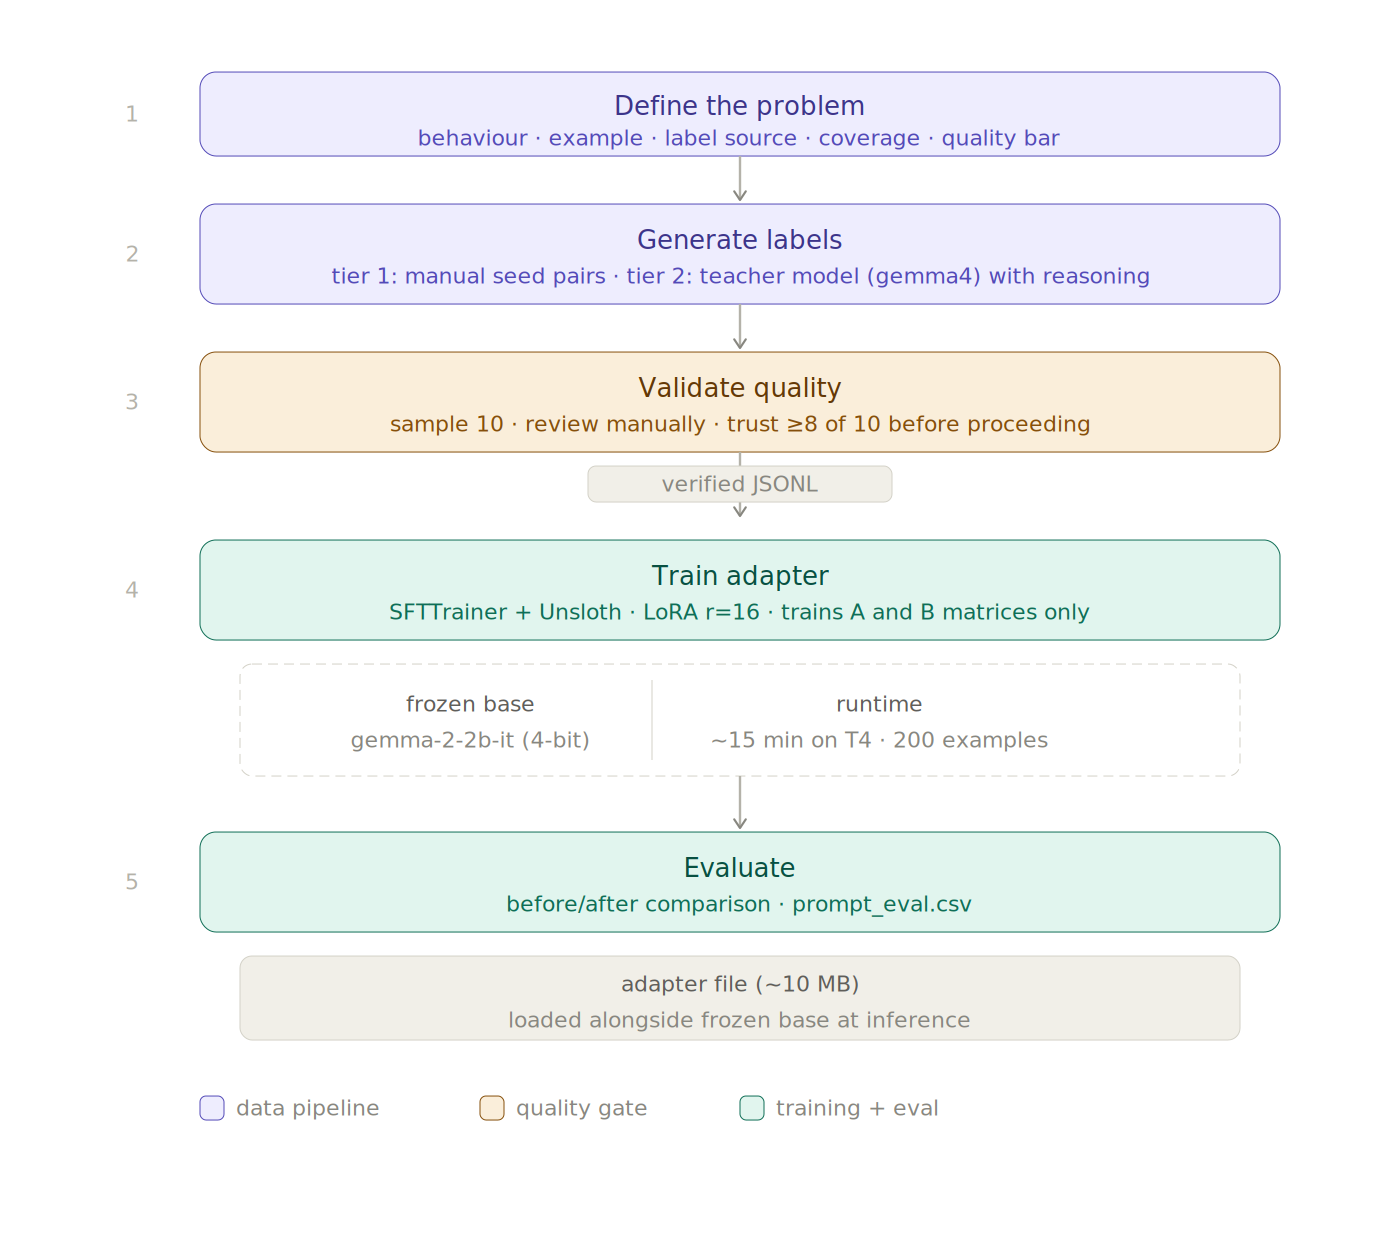

---
## Beyond Adapters

The adapter is trained and evaluated. You know how to tune for efficiency and how to close accuracy gaps on hard cases. Here's where these techniques are heading.

### Inference-Time Compute Scaling

Fine-tuning changes model weights — but there's a parallel direction: spending more compute *at inference time* rather than at training time.

The core idea: instead of training the model to get the answer right on the first try, you give it more steps to reach the answer. Two common patterns:

- **Self-consistency:** generate N answers independently (with temperature > 0), take the majority vote. For our recipe classifier, generate 5 predictions and pick the most common. Works surprisingly well for borderline cases at the cost of 5× the inference time.
- **Iterative self-reflection *(sometimes called chain-of-thought with reflection)*:** generate an initial answer, then ask the model to critique its own reasoning and revise. The revision pass often catches the kind of skill-level errors we saw in Step 0.

Inference-time scaling doesn't require labeled data or GPU training — which makes it attractive when you can't collect training examples. The trade-off: it multiplies your inference latency and cost by the number of generation passes. For a production classifier running on thousands of recipes, that cost adds up fast.

> **The decision:** use inference-time scaling when you can't collect training data or when the task changes frequently (adapter retraining is expensive). Use fine-tuning when you have stable labeled data and need consistent, fast inference.

### Reinforcement Learning Fine-tuning

The adapters we trained this week used **supervised fine-tuning (SFT)**: we provided correct input-output pairs and the model learned to match them. This works well when you know what the right output looks like.

But some tasks don't have a clear "right answer" — they have a better or worse answer. For those, **reinforcement learning from human feedback (RLHF)** trains the model using a reward signal instead of labeled examples: "your answer was better than your last one."

A more recent and efficient variant is **GRPO (Group Relative Policy Optimization)**, used in models like DeepSeek-R1. A reward function still scores every output — what GRPO drops is the separate **value/critic network** that PPO requires. Instead, it generates a group of candidate outputs, scores them all, and uses the group's average reward as the baseline. Outputs that scored above average are reinforced; those below are suppressed. This is what enables "reasoning models" that think step-by-step before answering.

For our recipe use case: RLHF could train the model using human ratings of whether a time estimate felt accurate, rather than requiring exact category labels. This is useful when the boundary between B and C is genuinely ambiguous — the reward captures human judgment better than a hard label.

> **Not in scope for this course** — RL fine-tuning requires more compute and a more complex training loop. But the data you're building (skill-stratified human-validated pairs) is the foundation of an RLHF pipeline if you want to pursue it further.

### Tuning for Agentic AI

When the model is an agent — taking actions, using tools, operating in a loop — fine-tuning the task changes fundamentally.

For a classifier, one training example is one (input, label) pair. For an agent, one training example is a **trajectory**: a sequence of (observation → action → result) steps that leads to a goal. The model needs to learn not just the right answer, but the right *sequence of decisions* to reach it.

This introduces new challenges:
- **Dataset construction:** trajectories are expensive to collect — you need a working agent to generate them, or humans to demonstrate the behavior
- **Reward design:** what does "correct" mean for a 10-step tool-calling sequence? Partial credit? Final-state only?
- **Distribution shift:** the model generates its own training data (via rollouts), which means errors compound across steps in a way they don't for classification

For students whose Module 1 problem statement involved an agentic use case (a multi-step workflow, a tool-using assistant): your Module 4 eval set is still the right starting point — but instead of input-output pairs, you'll need to collect successful and unsuccessful agent trajectories to label.

> **The direction:** agentic fine-tuning is an active research area. The techniques (behavior cloning, DPO on trajectories, process reward models) are maturing fast. The adapter skills from this week apply directly — the main new challenge is dataset construction.

---

## Key Takeaways

1. **Fine-tuning starts with an eval set.** Without a measured baseline you can't know whether the adapter helped — or made things worse. The Module 4 `prompt_eval.csv` is what makes the before/after comparison meaningful.

2. **LoRA makes fine-tuning accessible.** By training only ~1% of parameters (the low-rank decomposition matrices), fine-tuning a 2B-parameter model fits on a consumer GPU. QLoRA shrinks it further — the entire training run fits in Colab's free T4.

3. **Choose your goal before designing the dataset.** Option A (efficiency: same accuracy, fewer tokens) and Option B (accuracy gap: fix failures on a specific slice) require different data, different label strategies, and different success metrics. Mixing them produces a dataset that serves neither goal well.

4. **Dataset design is more important than hyperparameters.** The five questions — behavior, example format, label source, coverage, validation — determine whether the adapter learns the right thing. Hyperparameters tune how well it learns; they can't fix a bad dataset.

5. **The adapter is only as good as its labels.** Sample 10 examples and verify ≥8 before training. A dataset of confident but wrong teacher-model labels trains the adapter to be confidently wrong.

---

**Your assignment:**

1. Review your Module 4 eval results — identify your failure pattern (is this an Option A or Option B problem?)
2. Work through the 5-question framework for your own domain
3. Design and generate a fine-tuning dataset for your use case
4. Train a LoRA adapter and measure before/after accuracy against your `prompt_eval.csv`

To start your assignment, run in the Claude Code terminal:
```
Use assignment-partner skill to help me with this week's work.
```